In [1]:
import torch
import numpy as np

emb = torch.load(
    "embeddings/fold_4_embeddings.pt"
)

tissue_emb = emb["epoch99"]["tissue"]
plasma_emb = emb["epoch99"]["plasma"]


patients = sorted(
    set(tissue_emb.keys()) &
    set(plasma_emb.keys())
)

print(len(patients))

10


In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
def plot(tissue_emb, plasma_emb,pca,  fold, proj = False, epoch=0):

    patients = sorted(
    set(tissue_emb.keys()) &
    set(plasma_emb.keys())
)
    # Create a color mapping for patients
    colors = cm.get_cmap("tab20", len(patients))
    patient_colors = {
        patient: colors(i)
        for i, patient in enumerate(patients)
    }

    plt.figure(figsize=(7,6))



    for patient in patients:

        color = patient_colors[patient]

        t = pca.transform(
            tissue_emb[patient].numpy().reshape(1,-1)
        )[0]

        p = pca.transform(
            plasma_emb[patient].numpy().reshape(1,-1)
        )[0]


        plt.scatter(
            t[0],
            t[1],
            marker="o",
            color = color,
            label="Tissue" if patient == patients[0] else ""
        )

        plt.scatter(
            p[0],
            p[1],
            marker="^",
            color=color,
            label="Plasma" if patient == patients[0] else ""

        )


        plt.plot(
            [t[0],p[0]],
            [t[1],p[1]],
            color=color,
            alpha=0.3
        )

    if proj == True:
        emb_type = 'projected embedding'
    else:
        emb_type = 'encoded embedding'
    plt.title(
        f"Patient-wise tissue-plasma {emb_type} alignment after {epoch} epochs"
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()


    plt.savefig(f'embeddings/plots/embeddings_fold_{fold}_{epoch}_{emb_type}.png',
        bbox_inches="tight")
    plt.show()




In [24]:
def compute_PCA(plasma_emb, tissue_emb):
    X = []
    labels = []
    modalities = []
    patients = sorted(
        set(tissue_emb.keys()) &
        set(plasma_emb.keys())
    )

    for patient in patients:

        X.append(
            tissue_emb[patient].numpy()
        )
        labels.append(patient)
        modalities.append("Tissue")


        X.append(
            plasma_emb[patient].numpy()
        )
        labels.append(patient)
        modalities.append("Plasma")


    X = np.stack(X)
    pca = PCA(
        n_components=2
    )

    X_pca = pca.fit_transform(X)
    return pca


In [25]:
def visualize_embeddings(proj=False):
    for fold in range(5):
        if proj:
            emb = torch.load(
            f"embeddings/fold_{fold}_embeddings_proj.pt"
            )
        else:
            emb = torch.load(
            f"embeddings/fold_{fold}_embeddings.pt"
            )

        tissue_emb_0 = emb["epoch0"]["tissue"]
        plasma_emb_0 = emb["epoch0"]["plasma"]

        tissue_emb_99 = emb["epoch99"]["tissue"]
        plasma_emb_99 = emb["epoch99"]["plasma"]

        pca_0 = compute_PCA(plasma_emb_0, tissue_emb_0)
        pca_99 = compute_PCA(plasma_emb_99, tissue_emb_99)

        plot(tissue_emb_0, plasma_emb_0,pca_0, fold=fold, proj=proj,epoch=0)
        plot(tissue_emb_99,plasma_emb_99,pca_99,fold=fold, proj=proj,epoch=99)







/home/bmep/plalfken/tmp/ipykernel_2859242/955123459.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


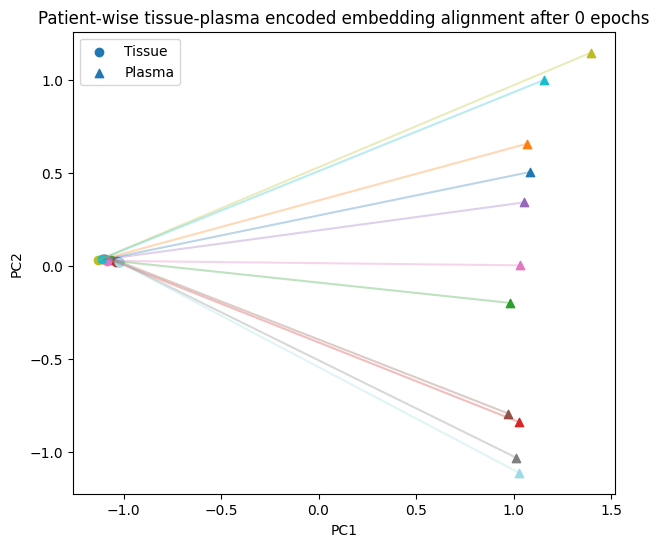

/home/bmep/plalfken/tmp/ipykernel_2859242/955123459.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


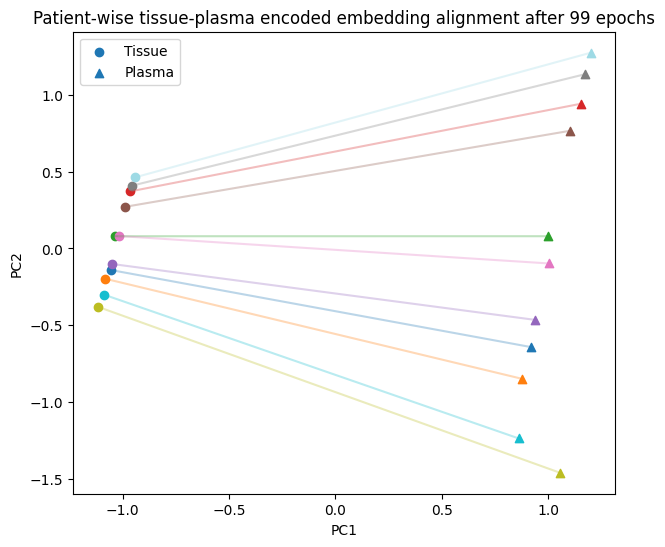

/home/bmep/plalfken/tmp/ipykernel_2859242/955123459.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


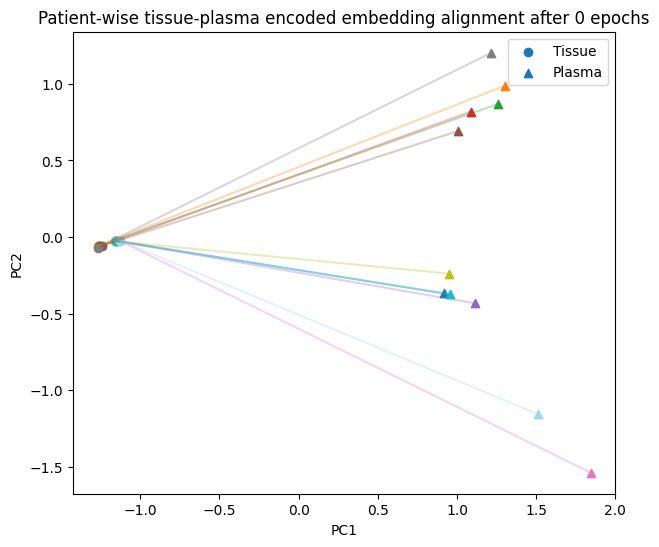

/home/bmep/plalfken/tmp/ipykernel_2859242/955123459.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


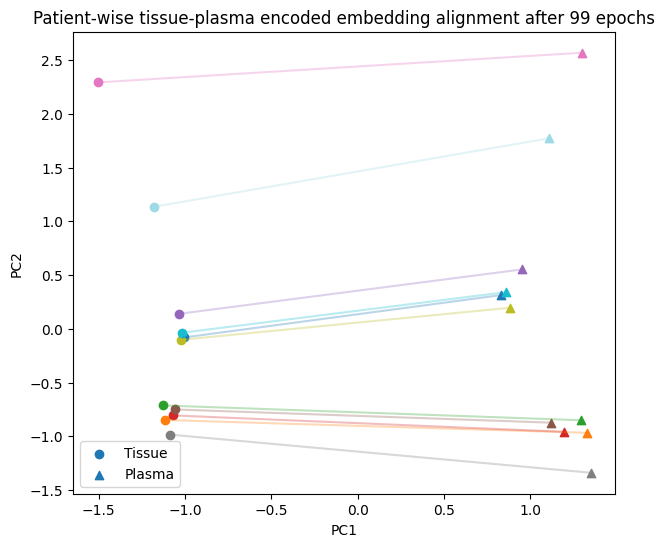

/home/bmep/plalfken/tmp/ipykernel_2859242/955123459.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


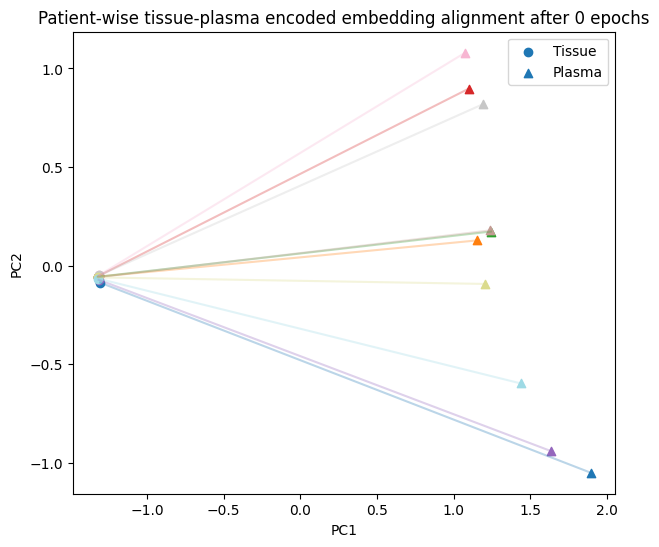

/home/bmep/plalfken/tmp/ipykernel_2859242/955123459.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


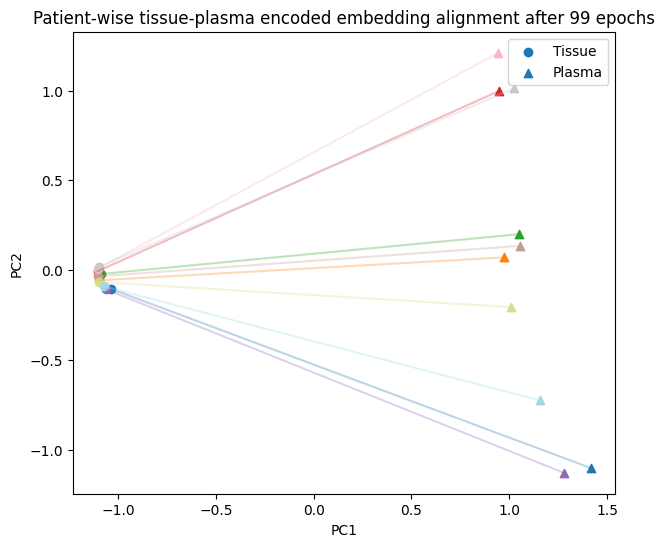

/home/bmep/plalfken/tmp/ipykernel_2859242/955123459.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


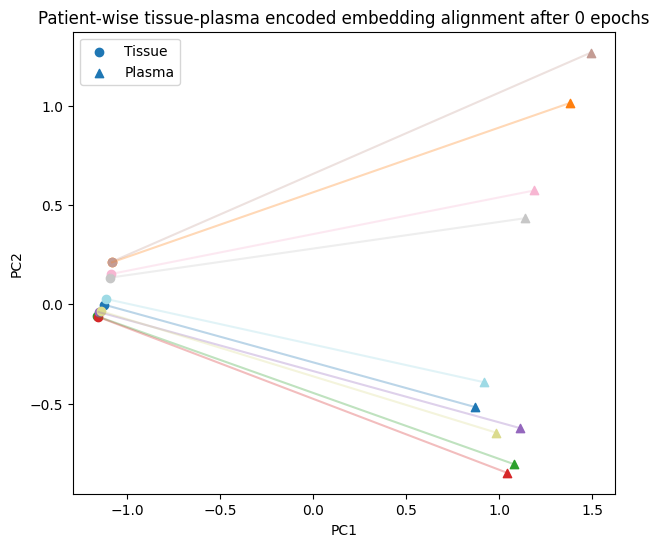

/home/bmep/plalfken/tmp/ipykernel_2859242/955123459.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


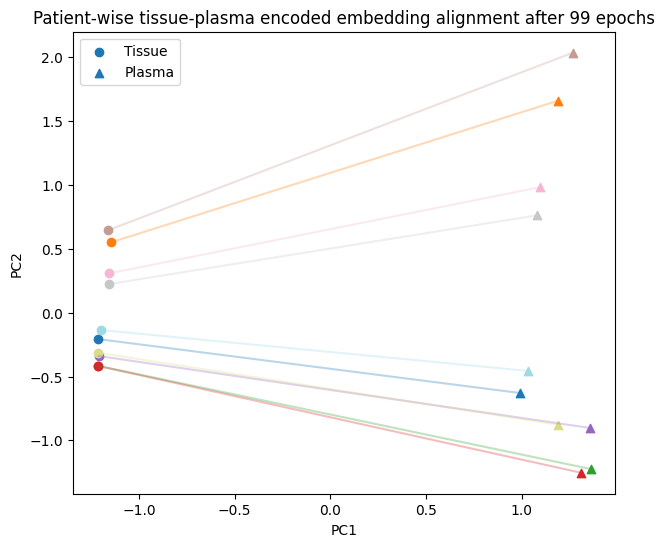

/home/bmep/plalfken/tmp/ipykernel_2859242/955123459.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


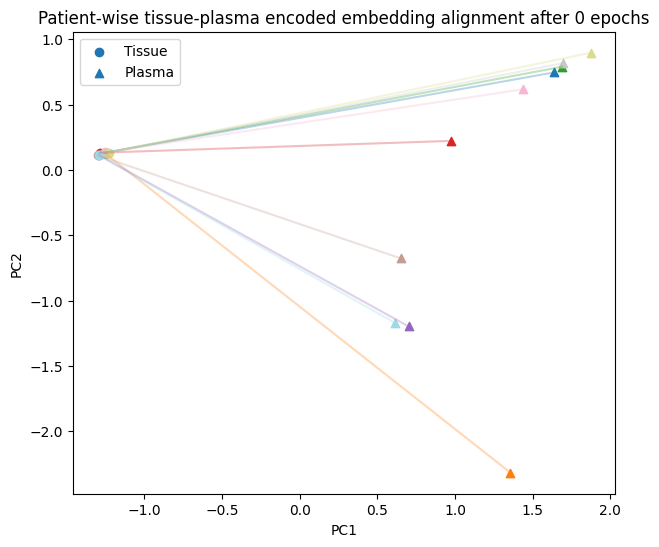

/home/bmep/plalfken/tmp/ipykernel_2859242/955123459.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


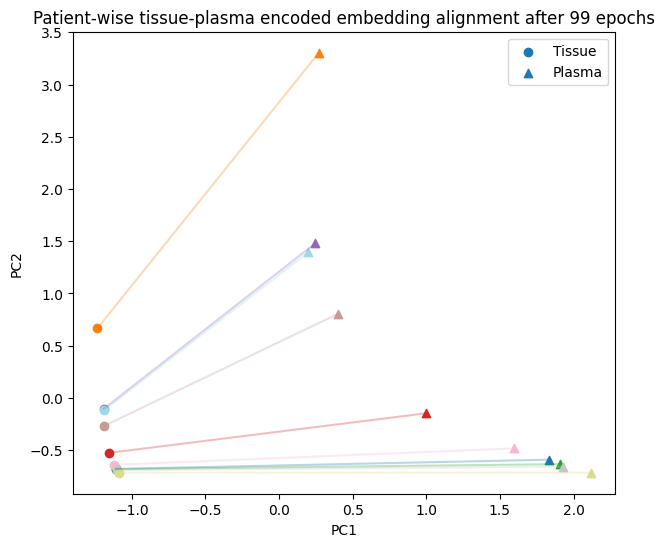

In [27]:
visualize_embeddings(proj=False)

In [2]:
X = []
labels = []
modalities = []

for patient in patients:

    X.append(
        tissue_emb[patient].numpy()
    )
    labels.append(patient)
    modalities.append("Tissue")


    X.append(
        plasma_emb[patient].numpy()
    )
    labels.append(patient)
    modalities.append("Plasma")


X = np.stack(X)

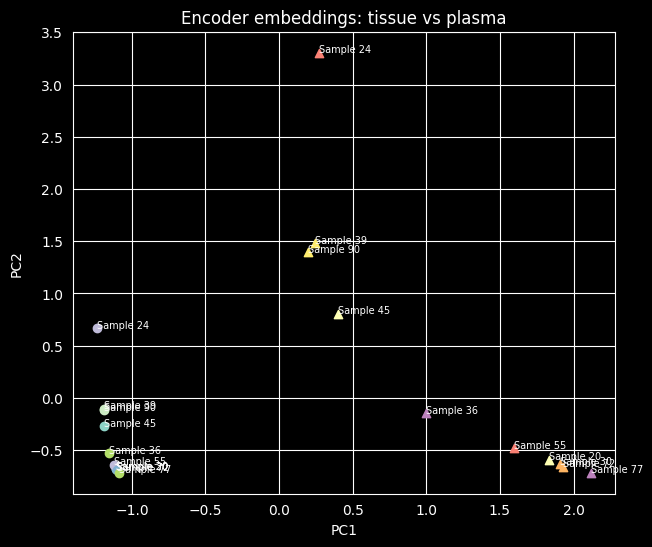

In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X)


plt.figure(figsize=(7,6))

for i in range(len(X_pca)):

    if modalities[i] == "Tissue":
        marker = "o"
    else:
        marker = "^"

    plt.scatter(
        X_pca[i,0],
        X_pca[i,1],
        marker=marker
    )

    plt.text(
        X_pca[i,0],
        X_pca[i,1],
        labels[i],
        fontsize=7
    )


plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Encoder embeddings: tissue vs plasma")

plt.show()

In [4]:
from sklearn.metrics.pairwise import cosine_distances

distances=[]

for patient in patients:

    d = cosine_distances(
        tissue_emb[patient].numpy().reshape(1,-1),
        plasma_emb[patient].numpy().reshape(1,-1)
    )[0,0]

    distances.append(d)


print(
    "Mean paired cosine distance:",
    np.mean(distances)
)
#
#

Mean paired cosine distance: 0.5806153


In [5]:
random_dist=[]

for i,p1 in enumerate(patients):

    p2 = patients[(i+1)%len(patients)]

    d = cosine_distances(
        tissue_emb[p1].numpy().reshape(1,-1),
        plasma_emb[p2].numpy().reshape(1,-1)
    )[0,0]

    random_dist.append(d)


print(
    "Mean random distance:",
    np.mean(random_dist)
)

Mean random distance: 0.62118995


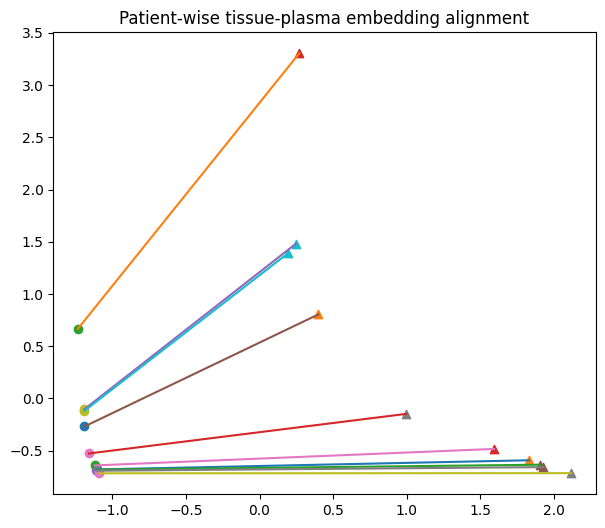

In [8]:
plt.figure(figsize=(7,6))


for patient in patients:

    t = pca.transform(
        tissue_emb[patient].numpy().reshape(1,-1)
    )[0]

    p = pca.transform(
        plasma_emb[patient].numpy().reshape(1,-1)
    )[0]


    plt.scatter(
        t[0],
        t[1],
        marker="o"
    )

    plt.scatter(
        p[0],
        p[1],
        marker="^"
    )


    plt.plot(
        [t[0],p[0]],
        [t[1],p[1]]
    )


plt.title(
    "Patient-wise tissue-plasma embedding alignment"
)

plt.show()